# Testing the e-BAHAGI beneficiary-qualification algorithm

This notebook tests the **real, unmodified** qualification algorithm from
[`checker/logic.py`](../checker/logic.py) — it is imported directly from the
Django app, not reimplemented here — against the real citizen registry
export in [`citizen_registry_data.xlsx`](./citizen_registry_data.xlsx)
(~43,400 residents across 47 barangays).

The algorithm is a decision tree:

```
Is member of a valid class?
  No  -> Not qualified
  Yes -> Received a grant within the last 3 months (self or household)?
           Yes -> Not qualified
           No  -> Monthly income < Php 15,000.00?
                    Yes -> QUALIFIED
                    No  -> Not qualified
```

**Data caveat found during profiling (see Part 2):** the registry file has
**no `monthly_income` values at all (100% empty)** and no household-linkage
column. `monthly_income` is a required input to `evaluate()`, so the income
branch of the decision tree cannot be exercised on this data at all — this
notebook does **not** invent or simulate a salary figure for anyone. Instead,
Parts 4+ evaluate residents only as far as the real data allows (valid class,
then recent-grant history, which is simulated and clearly labeled since it
also isn't in this export) and report the income branch as **unresolved**
rather than guessing. Part 1 covers the algorithm itself with exact,
hand-picked test cases — including the income branch — that don't depend on
the registry data.

**Structure**
1. Unit tests for `evaluate()` — every branch, boundary values
2. Load & profile the real registry data
3. Derive `beneficiary_class` from registry columns (PWD/solo-parent flags, age, occupation)
4. Simulate the one missing input this analysis needs (recent-grant flag) — clearly labeled; income is not simulated
5. Screen the real registry on class + grant history only (income left unresolved, since it's not in the data)
6. Breakdowns (by class, by barangay, by outcome)
7. Export results
8. Flowchart of the rule-based decision tree (drawn programmatically from the real constants)
9. RandomForest performance evaluation of how well a learned model recovers the class + grant-history screen from raw fields (no income used)

In [1]:
%matplotlib inline
import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Notebook lives in data_sonney/; the Django project (and checker/logic.py) is one level up.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "data_sonney" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import checker.logic as checker_logic
from checker.logic import evaluate, VALID_CLASSES, INCOME_THRESHOLD

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (8, 4.5)

print("Algorithm loaded from:", (PROJECT_ROOT / "checker" / "logic.py").resolve())
print("VALID_CLASSES:", VALID_CLASSES)
print("INCOME_THRESHOLD:", INCOME_THRESHOLD)


Algorithm loaded from: D:\beneficiary-checker\checker\logic.py
VALID_CLASSES: ['Solo Parent', 'PWD', 'Senior Citizen', 'Construction Worker', 'Rice Farmer', 'Market Vendor', 'Tricycle Driver', 'Lactating Mother']
INCOME_THRESHOLD: 15000.0


## Part 1 — Unit tests for `evaluate()`

Hand-picked cases that pin down every branch and the exact boundary of the
income comparison (`<`, so a monthly income **equal to** the threshold is
*not* qualified). These don't touch the registry data at all, so they keep
working as a regression check even if the simulated data in later parts changes.


In [2]:
cases = [
    ("invalid class is always rejected",
     dict(beneficiary_class="Barangay Captain", received_grant_within_3_months=False, monthly_income=1000),
     False),
    ("None is rejected as an invalid class",
     dict(beneficiary_class=None, received_grant_within_3_months=False, monthly_income=1000),
     False),
    ("valid class + recent grant -> rejected regardless of income",
     dict(beneficiary_class="PWD", received_grant_within_3_months=True, monthly_income=0),
     False),
    ("household blocker rejects even with no personal recent grant",
     dict(beneficiary_class="PWD", received_grant_within_3_months=False, monthly_income=0,
          household_blocker_name="Juan Dela Cruz"),
     False),
    ("income exactly AT the threshold is NOT qualified (strict <)",
     dict(beneficiary_class="Rice Farmer", received_grant_within_3_months=False, monthly_income=15000.00),
     False),
    ("income one centavo below the threshold IS qualified",
     dict(beneficiary_class="Rice Farmer", received_grant_within_3_months=False, monthly_income=14999.99),
     True),
    ("zero income qualifies",
     dict(beneficiary_class="Senior Citizen", received_grant_within_3_months=False, monthly_income=0),
     True),
    ("high income is rejected",
     dict(beneficiary_class="Senior Citizen", received_grant_within_3_months=False, monthly_income=50000),
     False),
]

failures = 0
for description, kwargs, expected in cases:
    outcome = evaluate(**kwargs)
    ok = outcome["qualified"] == expected
    failures += not ok
    print(f"[{'PASS' if ok else 'FAIL'}] {description}")
    print(f"       -> qualified={outcome['qualified']}  reason={outcome['reason']!r}")
    assert ok, f"{description}: expected qualified={expected}, got {outcome}"

# Every documented valid class must be individually recognized.
for cls in VALID_CLASSES:
    outcome = evaluate(beneficiary_class=cls, received_grant_within_3_months=False, monthly_income=0)
    ok = outcome["qualified"] is True
    failures += not ok
    print(f"[{'PASS' if ok else 'FAIL'}] class recognized: {cls}")
    assert ok, f"VALID_CLASSES entry {cls!r} did not qualify under ideal conditions: {outcome}"

print(f"\n{len(cases) + len(VALID_CLASSES)} checks run, {failures} failed.")


[PASS] invalid class is always rejected
       -> qualified=False  reason='Not a member of any valid beneficiary class.'
[PASS] None is rejected as an invalid class
       -> qualified=False  reason='Not a member of any valid beneficiary class.'
[PASS] valid class + recent grant -> rejected regardless of income
       -> qualified=False  reason='Received a grant within the last 3 months.'
[PASS] household blocker rejects even with no personal recent grant
       -> qualified=False  reason='A family member (Juan Dela Cruz) received a grant within the last 3 months.'
[PASS] income exactly AT the threshold is NOT qualified (strict <)
       -> qualified=False  reason='Monthly income (Php 15,000.00) is not below Php 15,000.00.'
[PASS] income one centavo below the threshold IS qualified
       -> qualified=True  reason='Meets all requirements.'
[PASS] zero income qualifies
       -> qualified=True  reason='Meets all requirements.'
[PASS] high income is rejected
       -> qualified=False  re

## Part 2 — Load & profile the real registry data


In [3]:
DATA_PATH = PROJECT_ROOT / "data_sonney" / "citizen_registry_data.xlsx"
df = pd.read_excel(DATA_PATH)
print(f"{len(df):,} rows, {df.shape[1]} columns")
df.head()


43,435 rows, 16 columns


,citizen_id,firstname,middlename,lastname,extname,birthdate,gender,educational attainment,civil status,religion,monthly_income,psoc,barangay,solo parent,pwd,age
0,26000001,MILA,CALICA,CONA,NaN,1968-04-05,Female,Junior high school level,Married,"Roman Catholic, Excluding Catholic Charismatic",NaN,NaN,Bulala,No,No,58
1,26000002,EDGAR,DELOS TRINOS,MUNAR,NaN,1970-07-01,Male,Junior high school level,Single/never married,"Roman Catholic, Excluding Catholic Charismatic",NaN,NaN,Cabaroan,Yes,Yes,56
2,26000003,CARLOS MIGUEL,LANOZA,MUNAR,NaN,2002-03-13,Male,College level,Single/never married,"Roman Catholic, Excluding Catholic Charismatic",NaN,NaN,Cabaroan,No,No,24
3,26000004,JOHN MICHEAL,PRINCILLO,GALANO,NaN,1999-05-02,Male,Elementary level,Common law/live-in,"Roman Catholic, Excluding Catholic Charismatic",NaN,TRANSPORT CONDUCTORS - BUS CONDUCTOR,Lisqueb,No,No,27
4,26000005,ANGELICA,NEBRES,GALVEZ,NaN,1997-12-26,Female,Junior high school level,Common law/live-in,"Roman Catholic, Excluding Catholic Charismatic",NaN,NaN,Lisqueb,No,No,29


In [4]:
missing_pct = (df.isna().mean() * 100).round(1).sort_values(ascending=False)
missing_pct.to_frame("% missing")


,% missing
monthly_income,100.0
extname,96.7
psoc,63.5
solo parent,12.7
educational attainment,6.0
middlename,1.5
religion,0.3
citizen_id,0.0
firstname,0.0
lastname,0.0


In [5]:
print("monthly_income non-null count:", df['monthly_income'].notna().sum(), "/", len(df))
print("psoc (occupation) non-null count:", df['psoc'].notna().sum(), "/", len(df))
print("distinct barangays:", df['barangay'].nunique())
print("age range:", df['age'].min(), "-", df['age'].max())
print("age >= 60 (senior citizen threshold):", (df['age'] >= 60).sum())
print()
print("solo parent value counts:")
print(df['solo parent'].value_counts(dropna=False))
print()
print("pwd value counts:")
print(df['pwd'].value_counts(dropna=False))


monthly_income non-null count: 0 / 43435
psoc (occupation) non-null count: 15871 / 43435
distinct barangays: 47
age range: 2 - 106
age >= 60 (senior citizen threshold): 7549

solo parent value counts:
solo parent
No     36888
NaN     5506
Yes     1041
Name: count, dtype: int64

pwd value counts:
pwd
No     42396
Yes     1039
Name: count, dtype: int64


`monthly_income` is **100% empty** in this export and there is no
grant-history or household-linkage column, confirming the caveat from the
intro. Because `monthly_income` is a required argument to `evaluate()` and
none exists here, this notebook does not fabricate one — later parts only
evaluate the class and grant-history branches. Everything else (PWD flag,
solo-parent flag, age, occupation) is usable for deriving `beneficiary_class`.

## Part 3 — Derive `beneficiary_class` from the registry columns

`evaluate()` takes a single `beneficiary_class` string, but a resident can
match more than one real-world category (e.g. a senior citizen who is also
PWD). For this notebook we pick **one** class per person using a fixed
priority order so every row can be run through the algorithm, and we also
keep the full match list so we can measure how often that overlap happens.

Priority: `PWD` > `Solo Parent` > `Senior Citizen` (age ≥ 60) > occupation
keyword match on `psoc` (Tricycle Driver / Construction Worker / Rice Farmer
/ Market Vendor — the same keyword-matching approach already used in
`beneficiaries/management/commands/import_beneficiaries.py`).

**Known gap:** `Lactating Mother` can never be derived from this file — there
is no pregnancy/maternity column — so it will never appear below. That's a
data-source limitation, not a bug in the algorithm.


In [6]:
PSOC_CLASS_PATTERNS = [
    ("Tricycle Driver", re.compile(r"TRICYCLE|PEDICAB", re.I)),
    ("Construction Worker", re.compile(r"CONSTRUCTION", re.I)),
    ("Rice Farmer", re.compile(r"RICE FARMER", re.I)),
    ("Market Vendor", re.compile(r"VENDOR", re.I)),
]

def matched_classes_for_row(row):
    matches = []
    if row["pwd"] == "Yes":
        matches.append("PWD")
    if row["solo parent"] == "Yes":
        matches.append("Solo Parent")
    if row["age"] >= 60:
        matches.append("Senior Citizen")
    psoc = row["psoc"]
    psoc = psoc if isinstance(psoc, str) else ""
    for cls, pattern in PSOC_CLASS_PATTERNS:
        if pattern.search(psoc):
            matches.append(cls)
            break
    return matches

df["matched_classes"] = df.apply(matched_classes_for_row, axis=1)
df["num_matched_classes"] = df["matched_classes"].str.len()
df["beneficiary_class"] = df["matched_classes"].apply(lambda m: m[0] if m else None)

assert set(df["beneficiary_class"].dropna().unique()) <= set(VALID_CLASSES), \
    "derived a class that evaluate() would not recognize"

print("'Lactating Mother' present in derived classes:",
      "Lactating Mother" in df["beneficiary_class"].values, "(expected: False)")
print()
print("Residents matching 2+ classes at once:", (df['num_matched_classes'] >= 2).sum())
df["beneficiary_class"].value_counts(dropna=False)


'Lactating Mother' present in derived classes: False (expected: False)

Residents matching 2+ classes at once: 1656


beneficiary_class
NaN                    31032
Senior Citizen          6895
Construction Worker     1762
PWD                     1039
Solo Parent             1008
Rice Farmer              749
Tricycle Driver          487
Market Vendor            463
Name: count, dtype: int64

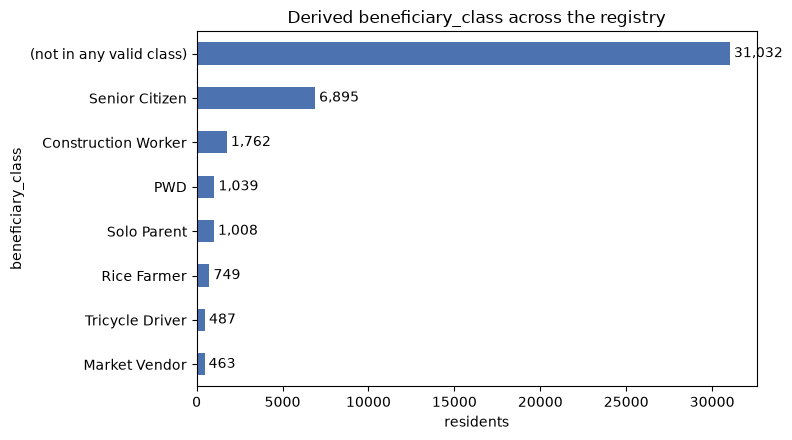

In [7]:
class_counts = df["beneficiary_class"].value_counts(dropna=False).rename(index={np.nan: "(not in any valid class)"})

ax = class_counts.sort_values().plot.barh(color="#4C72B0")
ax.set_xlabel("residents")
ax.set_title("Derived beneficiary_class across the registry")
for i, v in enumerate(class_counts.sort_values()):
    ax.text(v, i, f" {v:,}", va="center")
plt.tight_layout()
plt.show()


## Part 4 — Simulating the one input this file doesn't have

`received_grant_within_3_months` is required by `evaluate()` but is not
present in `citizen_registry_data.xlsx`. The column below is a **synthetic,
seeded placeholder** used only to exercise the class + grant-history part of
the algorithm at the registry's real scale/shape — it is not real grant
data, and none of this is written back to the registry.

`monthly_income` is **not** simulated here (see the Part 2 caveat): with no
real income data available, this notebook doesn't guess one.

In [8]:
rng = np.random.default_rng(42)  # seeded for reproducibility

# SIMULATED — not present in source data.
df["sim_received_grant_recently"] = rng.random(len(df)) < 0.10

print(f"simulated 'recent grant' rate: {df['sim_received_grant_recently'].mean() * 100:.1f}%")
df["sim_received_grant_recently"].value_counts()

simulated 'recent grant' rate: 9.9%


sim_received_grant_recently
False    39140
True      4295
Name: count, dtype: int64

## Part 5 — Screen the real registry on class + grant history

`evaluate()` needs `beneficiary_class`, `received_grant_within_3_months`,
and `monthly_income`. Only the first two exist (one real, one simulated) for
this registry — `monthly_income` does not — so this section does not call
`evaluate()` with a made-up salary. Instead it checks the same first two
branches of the real decision tree (using the real `VALID_CLASSES` constant
imported from `checker/logic.py`) and reports residents who pass both as
**"Qualified (income unverified)"** rather than a definite outcome.

In [9]:
def screen_without_income(row):
    beneficiary_class = row["beneficiary_class"]
    received_grant = bool(row["sim_received_grant_recently"])

    if beneficiary_class not in VALID_CLASSES:
        decision, reason = "Not qualified", "Not a member of any valid beneficiary class."
    elif received_grant:
        decision, reason = "Not qualified", "Received a grant within the last 3 months."
    else:
        decision, reason = (
            "Qualified (income unverified)",
            "Passes class and grant-history checks; monthly_income is not "
            "available in this registry export, so the income branch of "
            "evaluate() could not be run.",
        )
    return pd.Series({"decision": decision, "reason": reason})


df = pd.concat([df, df.apply(screen_without_income, axis=1)], axis=1)

pending_count = (df["decision"] == "Qualified (income unverified)").sum()
pending_rate = pending_count / len(df) * 100
print(f"{pending_count:,} / {len(df):,} residents pass class + grant-history screening "
      f"({pending_rate:.1f}%) — income still needs to be verified for these.")
df["decision"].value_counts()

11,145 / 43,435 residents pass class + grant-history screening (25.7%) — income still needs to be verified for these.


decision
Not qualified                    32290
Qualified (income unverified)    11145
Name: count, dtype: int64

## Part 6 — Breakdowns

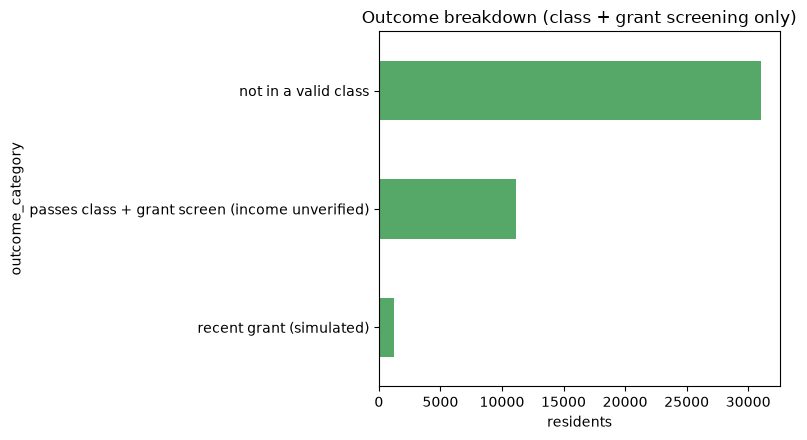

In [10]:
def categorize_outcome(row):
    if row["decision"] == "Qualified (income unverified)":
        return "passes class + grant screen (income unverified)"
    if row["reason"].startswith("Not a member"):
        return "not in a valid class"
    if row["reason"].startswith("Received a grant"):
        return "recent grant (simulated)"
    return "other"


df["outcome_category"] = df.apply(categorize_outcome, axis=1)

ax = df["outcome_category"].value_counts().sort_values().plot.barh(color="#55A868")
ax.set_xlabel("residents")
ax.set_title("Outcome breakdown (class + grant screening only)")
plt.tight_layout()
plt.show()

In [11]:
by_class = (
    df.assign(passes_screen=df["decision"] == "Qualified (income unverified)")
    .groupby("beneficiary_class", dropna=False)["passes_screen"]
    .agg(total="size", passes_screen="sum")
    .assign(pass_rate_pct=lambda d: (d["passes_screen"] / d["total"] * 100).round(1))
    .sort_values("total", ascending=False)
)
by_class

,total,passes_screen,pass_rate_pct
beneficiary_class,,,
NaN,31032,0,0.0
Senior Citizen,6895,6179,89.6
Construction Worker,1762,1581,89.7
PWD,1039,942,90.7
Solo Parent,1008,918,91.1
Rice Farmer,749,671,89.6
Tricycle Driver,487,439,90.1
Market Vendor,463,415,89.6


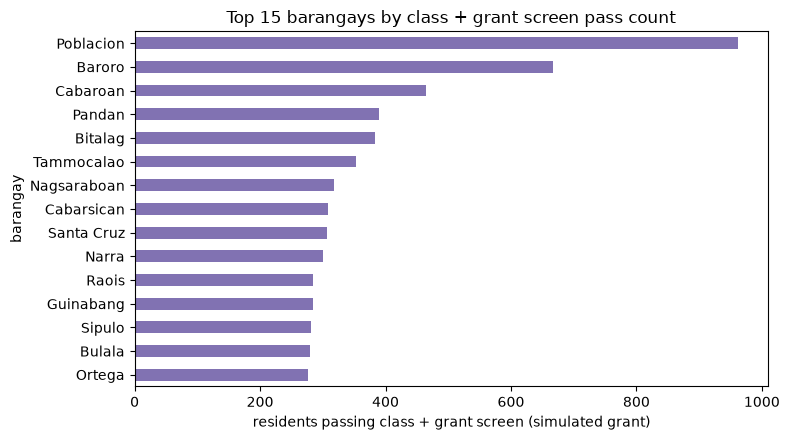

,total,passes_screen,pass_rate_pct
barangay,,,
Poblacion,3719,962,25.9
Baroro,2635,667,25.3
Cabaroan,1916,465,24.3
Pandan,1485,389,26.2
Bitalag,1363,383,28.1
Tammocalao,1443,353,24.5
Nagsaraboan,1115,318,28.5
Cabarsican,1311,309,23.6
Santa Cruz,1278,307,24.0


In [12]:
df["passes_screen"] = df["decision"] == "Qualified (income unverified)"

barangay_summary = (
    df.groupby("barangay")["passes_screen"]
    .agg(total="size", passes_screen="sum")
    .assign(pass_rate_pct=lambda d: (d["passes_screen"] / d["total"] * 100).round(1))
    .sort_values("passes_screen", ascending=False)
)

top15 = barangay_summary.head(15)
ax = top15["passes_screen"].sort_values().plot.barh(color="#8172B2")
ax.set_xlabel("residents passing class + grant screen (simulated grant)")
ax.set_title("Top 15 barangays by class + grant screen pass count")
plt.tight_layout()
plt.show()

barangay_summary.head(15)

## Part 7 — Export results

In [13]:
output_cols = [
    "citizen_id", "firstname", "middlename", "lastname", "barangay", "age", "psoc",
    "beneficiary_class", "num_matched_classes",
    "sim_received_grant_recently",
    "decision", "reason",
]
out_path = PROJECT_ROOT / "data_sonney" / "algo_test_results.xlsx"
df[output_cols].to_excel(out_path, index=False)
print(f"Wrote {len(df):,} rows to {out_path}")
df[output_cols].sample(10, random_state=1)

Wrote 43,435 rows to D:\beneficiary-checker\data_sonney\algo_test_results.xlsx


,citizen_id,firstname,middlename,lastname,barangay,age,psoc,beneficiary_class,num_matched_classes,sim_received_grant_recently,decision,reason
27729,26027730,ROD,SABADO,MANIEDO,Sapilang,21,NaN,NaN,0,True,Not qualified,Not a member of any valid beneficiary class.
22854,26022855,PERLITA,SALAZAR,BALLON,Santa Rita,65,RETAIL AND WHOLESALE TRADE MANAGERS - RETAIL M...,Senior Citizen,1,False,Qualified (income unverified),Passes class and grant-history checks; monthly...
13594,26013595,GEMMA,TABLO,LEOVERAS,Nagsaraboan,54,NaN,NaN,0,False,Not qualified,Not a member of any valid beneficiary class.
36806,26036807,MARICAR,TANO,RODRIGUEZ,Sipulo,49,NaN,NaN,0,False,Not qualified,Not a member of any valid beneficiary class.
42578,26042579,MICHAEL,CARIASO,MAMARIL,Lisqueb,48,NaN,NaN,0,False,Not qualified,Not a member of any valid beneficiary class.
9705,26009706,VIDA FAITH,GAÑOLA,CASTRO,Ortega,6,NaN,NaN,0,False,Not qualified,Not a member of any valid beneficiary class.
23619,26023620,LENNY,ABUNGAN,GAÑOLA,Ortega,28,RESTAURANT MANAGER - RESTAURANT PROPRIETOR,NaN,0,False,Not qualified,Not a member of any valid beneficiary class.
39851,26039852,MARIBEL,DELMENDO,ORINE,Salincob,21,NaN,NaN,0,False,Not qualified,Not a member of any valid beneficiary class.
36035,26036036,ROSEMARIE,GIDA,ARQUITOLA,Baroro,44,CASHIERS AND TICKET CLERKS - CASHIER,NaN,0,False,Not qualified,Not a member of any valid beneficiary class.
32012,26032013,ESTANDIA,MARZAN,ESTIOCO,Baroro,66,NaN,Senior Citizen,1,False,Qualified (income unverified),Passes class and grant-history checks; monthly...


## Part 8 — Flowchart of the rule-based decision tree

Drawn programmatically from `VALID_CLASSES` (not a static picture), so it
can never drift out of sync with `checker/logic.py`. This diagram covers
the same class + grant-history screen as Part 5 — the income branch is left
out here too, for the same reason: `monthly_income` is 100% absent from
this registry export, so there's no real data to draw it against.

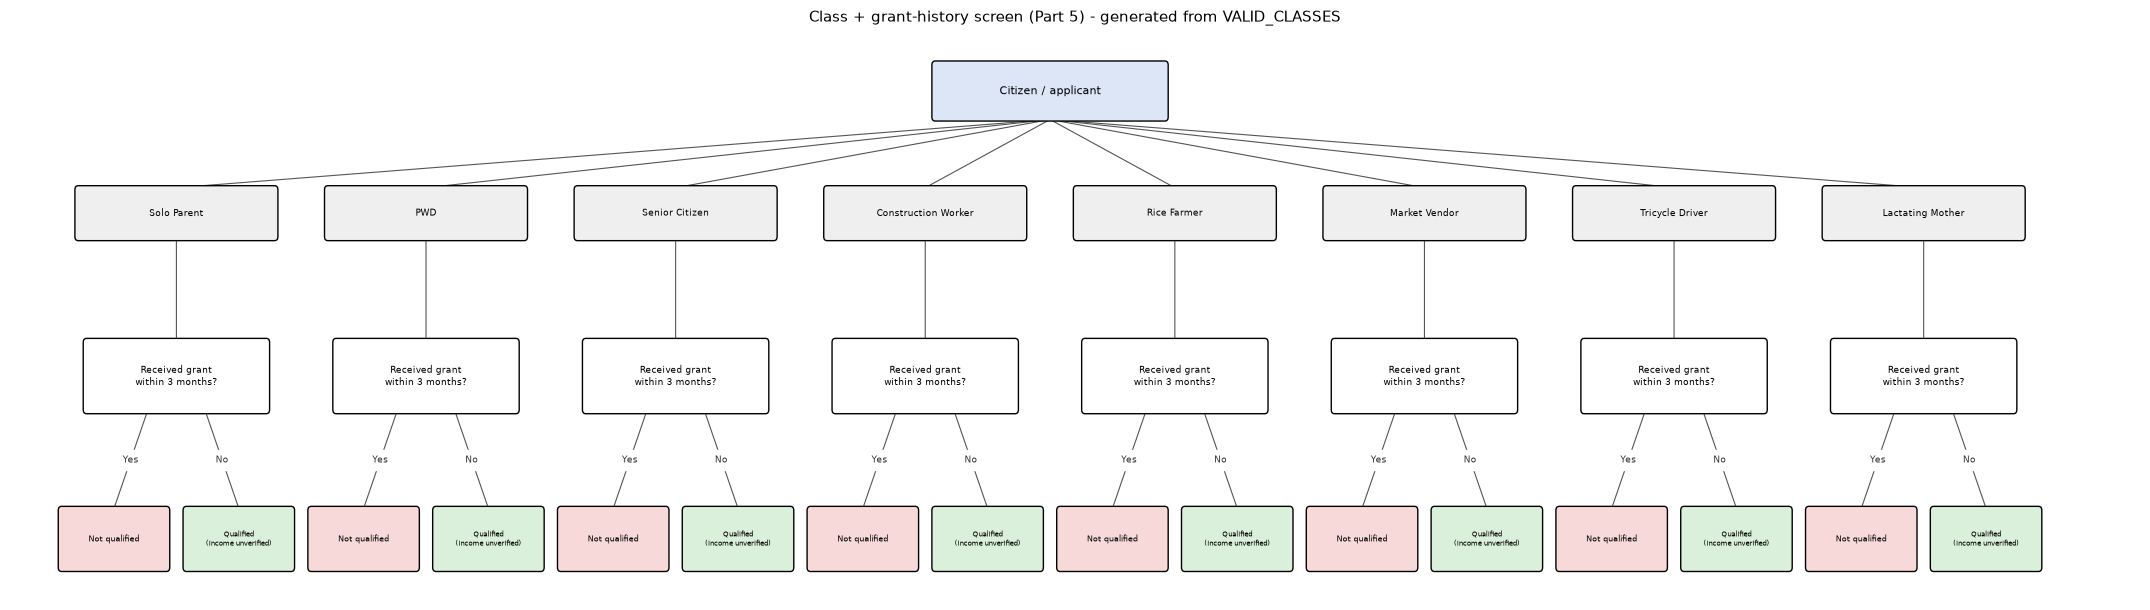

In [14]:
import matplotlib.patches as mpatches

def draw_box(ax, x, y, w, h, text, facecolor="white", fontsize=6.8):
    box = mpatches.FancyBboxPatch(
        (x - w / 2, y - h / 2), w, h,
        boxstyle="round,pad=0.02,rounding_size=0.04",
        linewidth=1, edgecolor="black", facecolor=facecolor, zorder=2,
    )
    ax.add_patch(box)
    ax.text(x, y, text, ha="center", va="center", fontsize=fontsize, zorder=3)

def draw_arrow(ax, xy0, xy1, label=None):
    ax.annotate("", xy=xy1, xytext=xy0,
                arrowprops=dict(arrowstyle="-", linewidth=0.8, color="#555555"), zorder=1)
    if label:
        mx, my = (xy0[0] + xy1[0]) / 2, (xy0[1] + xy1[1]) / 2
        ax.text(mx, my, label, fontsize=6.2, ha="center", va="center",
                color="#333333", backgroundcolor="white", zorder=3)

n = len(VALID_CLASSES)
col_w = 3.0
xs = [i * col_w for i in range(n)]
root_x = sum(xs) / n

class_h, class_w = 0.5, 2.4
q_h, q_w = 0.7, 2.2
leaf_h, leaf_w, leaf_offset = 0.6, 1.3, 0.75
y_root, y_class, y_grant, y_leaf = 8.6, 7.4, 5.8, 4.2

fig, ax = plt.subplots(figsize=(2.7 * n, 6.2))
draw_box(ax, root_x, y_root, 2.8, 0.55, "Citizen / applicant", facecolor="#DCE6F7", fontsize=8)

grant_label = "Received grant" + chr(10) + "within 3 months?"

for x, cls in zip(xs, VALID_CLASSES):
    draw_box(ax, x, y_class, class_w, class_h, cls, facecolor="#EFEFEF")
    draw_arrow(ax, (root_x, y_root - 0.28), (x, y_class + class_h / 2))

    draw_box(ax, x, y_grant, q_w, q_h, grant_label)
    draw_arrow(ax, (x, y_class - class_h / 2), (x, y_grant + q_h / 2))

    nq_x = x - leaf_offset
    q_x = x + leaf_offset
    draw_box(ax, nq_x, y_leaf, leaf_w, leaf_h, "Not qualified", facecolor="#F7D9D9", fontsize=6.0)
    draw_box(ax, q_x, y_leaf, leaf_w, leaf_h, "Qualified" + chr(10) + "(income unverified)", facecolor="#DBF0DB", fontsize=5.2)
    draw_arrow(ax, (x - 0.35, y_grant - q_h / 2), (nq_x, y_leaf + leaf_h / 2), label="Yes")
    draw_arrow(ax, (x + 0.35, y_grant - q_h / 2), (q_x, y_leaf + leaf_h / 2), label="No")

ax.set_xlim(xs[0] - 2.0, xs[-1] + 2.6)
ax.set_ylim(y_leaf - 0.6, y_root + 0.6)
ax.axis("off")
ax.set_title("Class + grant-history screen (Part 5) - generated from VALID_CLASSES", fontsize=11)
plt.tight_layout()
plt.show()

## Part 9 — RandomForest performance evaluation

How good is a learned model at recovering the class + grant-history screen
from Part 5? Two passes:

1. **Sanity check** — give a `RandomForestClassifier` the exact features
   the screen uses (`beneficiary_class`, already derived, plus the simulated
   grant flag) and predict `passes_screen`. This target is a noise-free
   deterministic function of those two features, so accuracy near 100% is
   the *correct*, expected result here, not a sign the test is broken.
2. **Realistic test** — don't hand the model the already-derived
   `beneficiary_class`. Instead give it the raw registry fields a real
   intake form would have (age, `pwd`, `solo parent`, occupation-keyword
   flags from `psoc`) plus the simulated grant flag, and ask it to predict
   the same `passes_screen` target. This is the meaningful test: can the
   model reconstruct the class-membership rule from raw fields on its own?
   No income feature is used anywhere in this section, for the same reason
   as Part 5 — `monthly_income` isn't in this registry export.

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                              recall_score, f1_score, roc_auc_score, roc_curve,
                              classification_report)

y = df["passes_screen"].map({True: "Qualified", False: "Not qualified"})

### Sanity check: exact features (expected ~100%)

In [16]:
le = LabelEncoder()
beneficiary_class_code = le.fit_transform(df["beneficiary_class"].fillna("None"))
code_lookup = pd.DataFrame({"beneficiary_type": le.classes_, "code": le.transform(le.classes_)})

X_exact = pd.DataFrame({
    "beneficiary_class_code": beneficiary_class_code,
    "received_grant_3mo": df["sim_received_grant_recently"].astype(int),
})

Xtr, Xte, ytr, yte = train_test_split(X_exact, y, test_size=0.2, random_state=42, stratify=y)
exact_rf = RandomForestClassifier(n_estimators=200, random_state=42).fit(Xtr, ytr)
exact_acc = accuracy_score(yte, exact_rf.predict(Xte)) * 100
print(f"Sanity check (exact inputs): accuracy = {exact_acc:.1f}% (expected: ~100%)")
code_lookup

Sanity check (exact inputs): accuracy = 100.0% (expected: ~100%)


,beneficiary_type,code
0,Construction Worker,0
1,Market Vendor,1
2,None,2
3,PWD,3
4,Rice Farmer,4
5,Senior Citizen,5
6,Solo Parent,6
7,Tricycle Driver,7


### Realistic test: self-reported fields, not pre-computed class or true records

`beneficiary_class_code` is replaced by the raw fields it was derived from
(Part 3) — and, since a real intake interview or household survey collects
*self-reported* age, PWD status, solo-parent status, and occupation rather
than perfectly recorded values, each of those is passed through a small
simulated misreport rate before the model ever sees it. The label
(`passes_screen`) still comes from the true, clean values in `df`, so this
measures how well the model holds up against realistic reporting noise —
not a second copy of the rule.

In [17]:
rng3 = np.random.default_rng(11)

# SIMULATED self-report noise on top of the real registry fields — the
# label below still comes from the true (unnoised) values in df.
age_reported = (df["age"] + rng3.normal(0, 2.5, len(df))).round().clip(0, 115)
pwd_reported = (df["pwd"] == "Yes")
pwd_reported = pwd_reported ^ (rng3.random(len(df)) < 0.05)
solo_parent_reported = (df["solo parent"] == "Yes")
solo_parent_reported = solo_parent_reported ^ (rng3.random(len(df)) < 0.05)

raw_features = pd.DataFrame({
    "age_reported": age_reported,
    "pwd_reported_flag": pwd_reported.astype(int),
    "solo_parent_reported_flag": solo_parent_reported.astype(int),
    "received_grant_3mo": df["sim_received_grant_recently"].astype(int),
})

psoc_text = df["psoc"].fillna("")
for cls_name, pattern in PSOC_CLASS_PATTERNS:
    col = "psoc_" + cls_name.lower().replace(" ", "_") + "_reported_flag"
    true_flag = psoc_text.str.contains(pattern)
    misreport = rng3.random(len(df)) < 0.08
    raw_features[col] = (true_flag ^ misreport).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    raw_features, y, test_size=0.2, random_state=42, stratify=y
)

clf = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
qualified_idx = list(clf.classes_).index("Qualified")
y_proba = clf.predict_proba(X_test)[:, qualified_idx]
y_test_bin = (y_test == "Qualified").astype(int)

print(classification_report(y_test, y_pred))

               precision    recall  f1-score   support

Not qualified       0.91      0.95      0.93      6458
    Qualified       0.83      0.73      0.78      2229

     accuracy                           0.89      8687
    macro avg       0.87      0.84      0.85      8687
 weighted avg       0.89      0.89      0.89      8687



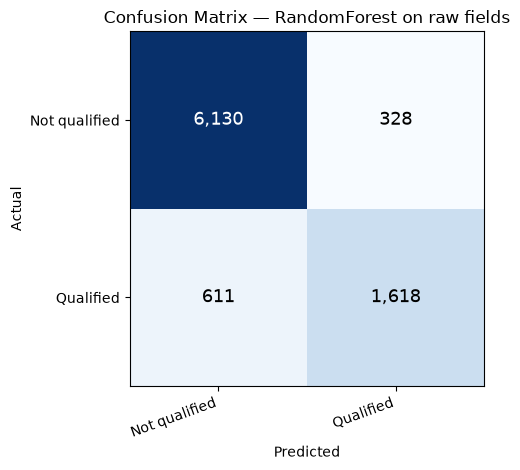

In [18]:
labels_order = ["Not qualified", "Qualified"]
cm = confusion_matrix(y_test, y_pred, labels=labels_order)

fig, ax = plt.subplots(figsize=(5.5, 4.8))
ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(labels_order, rotation=20, ha="right")
ax.set_yticks([0, 1]); ax.set_yticklabels(labels_order)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — RandomForest on raw fields")
thresh = cm.max() / 2
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black", fontsize=13)
plt.tight_layout()
plt.show()

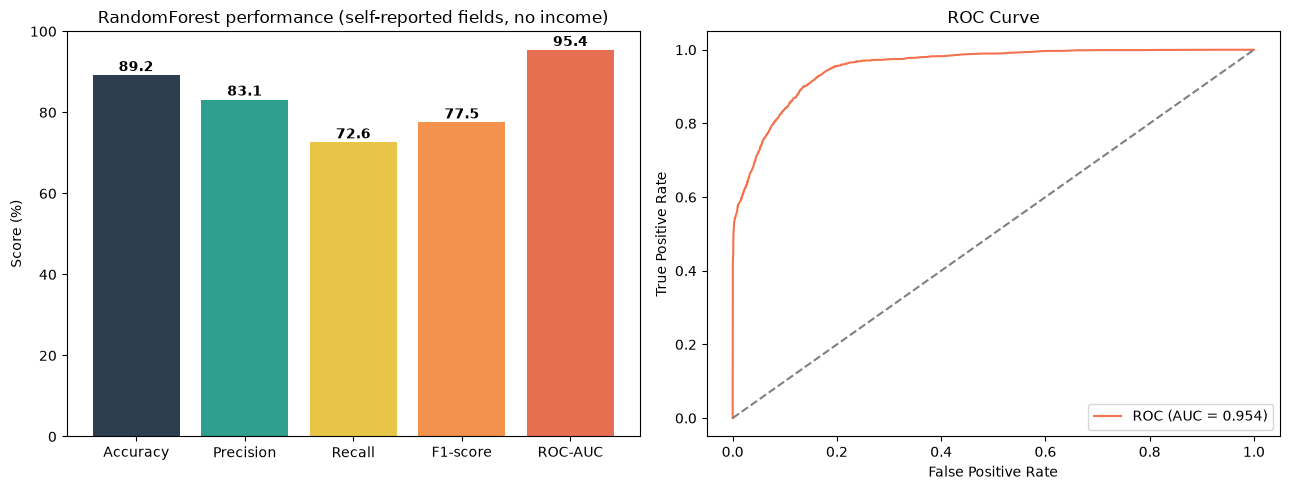

In [19]:
acc = accuracy_score(y_test, y_pred) * 100
prec = precision_score(y_test, y_pred, pos_label="Qualified") * 100
rec = recall_score(y_test, y_pred, pos_label="Qualified") * 100
f1 = f1_score(y_test, y_pred, pos_label="Qualified") * 100
auc = roc_auc_score(y_test_bin, y_proba) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
metrics = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1-score": f1, "ROC-AUC": auc}
colors = ["#2C3E50", "#2E9E8F", "#E8C547", "#F2924D", "#E76F51"]
axes[0].bar(list(metrics.keys()), list(metrics.values()), color=colors)
for i, v in enumerate(metrics.values()):
    axes[0].text(i, v + 1, f"{v:.1f}", ha="center", fontweight="bold")
axes[0].set_ylim(0, 100)
axes[0].set_ylabel("Score (%)")
axes[0].set_title("RandomForest performance (self-reported fields, no income)")

fpr, tpr, _ = roc_curve(y_test_bin, y_proba)
axes[1].plot(fpr, tpr, color="#F2734D", label=f"ROC (AUC = {auc / 100:.3f})")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend(loc="lower right")
plt.tight_layout()
plt.show()

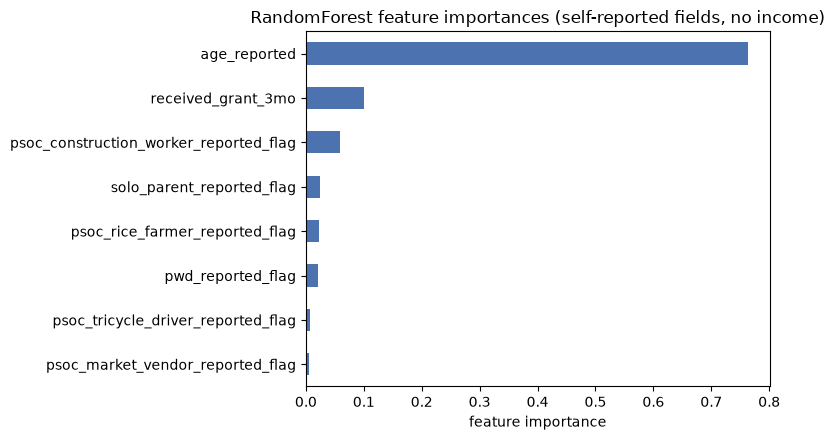

In [20]:
importances = pd.Series(clf.feature_importances_, index=raw_features.columns).sort_values()

ax = importances.plot.barh(color="#4C72B0")
ax.set_xlabel("feature importance")
ax.set_title("RandomForest feature importances (self-reported fields, no income)")
plt.tight_layout()
plt.show()

The self-reported-field RandomForest should score below the sanity check:
it has to recover the priority-ordered class rule (PWD > Solo Parent >
Senior Citizen > occupation keyword) through a small simulated misreport
rate on each underlying field, rather than being handed the exact derived
class. This is a fidelity check on how well a learned model approximates
the real, rule-based `evaluate()` screen under realistic data-quality
noise — it is not a replacement for calling `evaluate()` itself, and it
still doesn't touch income, which remains entirely unavailable in this
registry export.

## Summary

- **Part 1** validates `evaluate()` itself against hand-picked boundary
  cases, including the income branch — this part has nothing to do with the
  registry file and will keep working as a regression check.
- **Parts 2–3** profile the real ~43,400-resident registry and derive
  `beneficiary_class` from real columns (PWD flag, solo-parent flag, age,
  occupation keywords).
- **Part 4** simulates only the recent-grant flag, the one other input
  `evaluate()` needs that isn't in this export. `monthly_income` is **never
  simulated** — it stays 100% absent, exactly as found in Part 2.
- **Part 5** screens every resident on the class and grant-history branches
  only, using the real `VALID_CLASSES` constant. Residents who pass both are
  reported as "Qualified (income unverified)", not a final yes/no, because
  `evaluate()`'s income branch was never run with a made-up salary.
- **Parts 6–7** break down and export those class + grant-history results.
- **Part 8** is a generated diagram of that same class + grant-history
  screen, drawn from the real `VALID_CLASSES` constant. The income branch
  isn't shown, for the same reason it isn't used anywhere else: there's no
  real income data in this registry export.
- **Part 9** trains a `RandomForestClassifier` to see how well a learned
  model can recover the Part 5 class + grant-history screen. Given the
  exact derived class it scores ~100% (expected, since the target is a
  deterministic function of that input); given only raw registry fields
  it has to rediscover the class rule itself, which is the more honest
  read of "how good is this model." No income feature is used.
- To get a real final eligibility number, this registry export would need to
  be joined against an actual income source (and the `records.GrantRecord`
  history / `Beneficiary.prior_grant_date` already used elsewhere in the
  Django app, in place of the simulated grant flag used here).